<a href="https://colab.research.google.com/github/MakarenaAmpuero/retail-sales-analysis/blob/development/Proyecto_Parte_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análisis de Ventas en una Tienda Retail Nombre: Makarena Ampuero Curso: Data Science Fecha: 04 de Mayo 2026

# Introducción

En esta parte del proyecto se realiza un análisis exploratorio de datos (EDA) del dataset de ventas de una tienda retail. El objetivo es entender mejor los datos, ver cómo se comportan las variables y detectar patrones o valores atípicos.

Para esto se utilizan herramientas como Python, Pandas, NumPy y Matplotlib, junto con gráficos como histogramas, boxplots, gráficos de dispersión y de líneas. Con esto se puede tener una visión general de las ventas y su comportamiento en el tiempo.

# 1. Importar librerías

Primero se importa Pandas y Numpy.

In [23]:
import pandas as pd
import numpy as np

print("Pandas y numpy cargado correctamente")

Pandas y numpy cargado correctamente


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Cargar Dataset

Se carga el archivo CSV en un DataFrame, ya que Pandas facilita el análisis y manipulación de datos tabulares.

In [24]:
df = pd.read_csv('/content/retail_sales_dataset.csv')

print("Dataset cargado correctamente")

print("Dimensión del archivo:", df.shape)

print("Primeras 10 filas del dataset:")
display(df.head(10))

print("Información general del dataset:", df.info)

print("Estadísticas descritivas:", df.describe)

print("Últimas 5 filas del dataset:")
display(df.tail(5))

Dataset cargado correctamente
Dimensión del archivo: (1000, 9)
Primeras 10 filas del dataset:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


Información general del dataset: <bound method DataFrame.info of      Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quant

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


# 3. Transformación de datos
Se crean nuevas columnas para facilitar el análisis y obtener información adicional a partir de los datos existentes.

In [25]:
# Nueva columna de ingreso total
df['Ingreso Calculado'] = df['Quantity'] * df['Price per Unit']

# Nueva columna de ventas
df['Sales'] = df['Quantity'] * df['Price per Unit']

# Nueva columna de descuentos

df['Discount'] = np.random.choice([0, 0.05, 0.1], size=len(df))


In [26]:
# Se normalizan las ventas para poder compararlas en una misma escala.
df['Ventas Normalizadas'] = (
    (df['Total Amount'] - df['Total Amount'].min()) /
    (df['Total Amount'].max() - df['Total Amount'].min())
)

#Histogramas

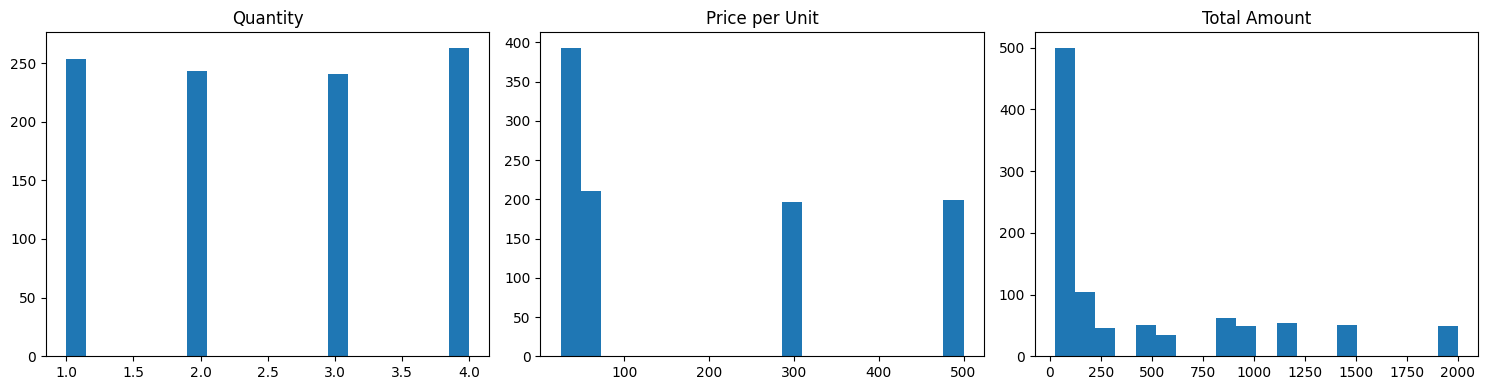

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(df['Quantity'], bins=20)
axs[0].set_title("Quantity")

axs[1].hist(df['Price per Unit'], bins=20)
axs[1].set_title("Price per Unit")

axs[2].hist(df['Total Amount'], bins=20)
axs[2].set_title("Total Amount")

plt.tight_layout()
plt.show()

Los histogramas permiten observar la distribución de las variables, identificando concentraciones de datos y posibles asimetrías.

#Boxplot

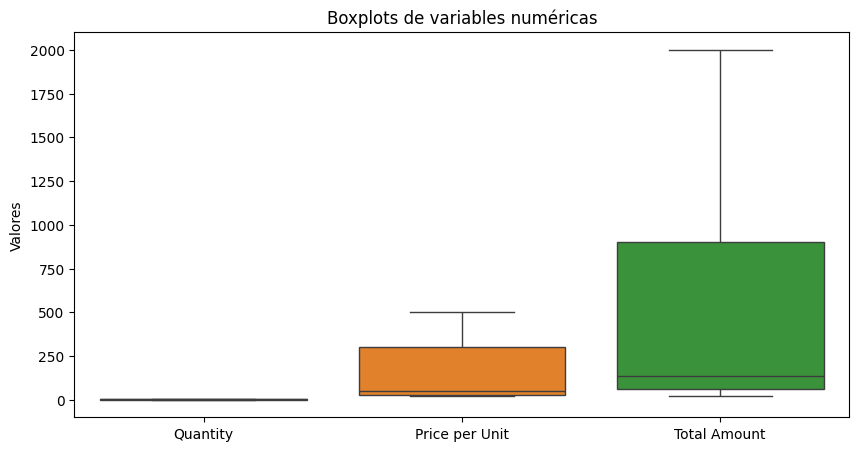

In [38]:
fig, ax = plt.subplots(figsize=(10,5))

sns.boxplot(
    data=df[['Quantity', 'Price per Unit', 'Total Amount']],
    ax=ax
)

ax.set_title("Boxplots de variables numéricas")
ax.set_ylabel("Valores")

plt.show()

Los boxplots permiten identificar valores atípicos (outliers) y observar la dispersión de los datos.

#Gráfico de líneas

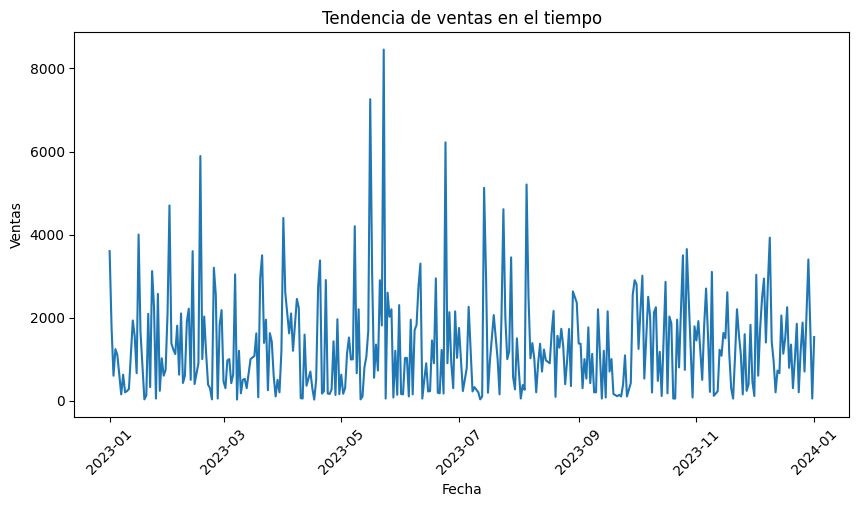

In [39]:
df['Date'] = pd.to_datetime(df['Date'])

ventas_tiempo = df.groupby('Date')['Sales'].sum()

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(ventas_tiempo.index, ventas_tiempo.values)

ax.set_title("Tendencia de ventas en el tiempo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas")

plt.xticks(rotation=45)
plt.show()

El gráfico de líneas muestra cómo varían las ventas a lo largo del tiempo, permitiendo identificar fluctuaciones o tendencias generales.

#Gráfico de dispersión

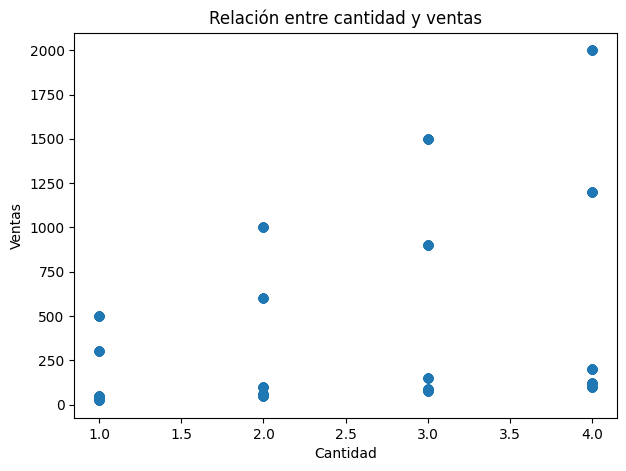

In [40]:
fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(df['Quantity'], df['Sales'])

ax.set_title("Relación entre cantidad y ventas")
ax.set_xlabel("Cantidad")
ax.set_ylabel("Ventas")

plt.show()

Se observa la relación entre la cantidad vendida y las ventas totales, lo que permite identificar si existe correlación entre ambas variables.

#Histograma y Boxplot

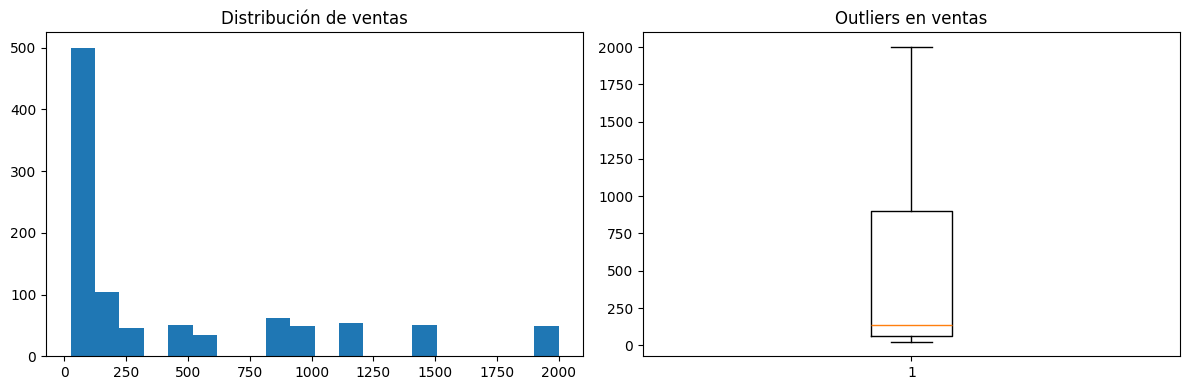

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))

axs[0].hist(df['Sales'], bins=20)
axs[0].set_title("Distribución de ventas")

axs[1].boxplot(df['Sales'])
axs[1].set_title("Outliers en ventas")

plt.tight_layout()
plt.show()

La combinación de ambos gráficos permite observar la distribución de las ventas y detectar valores atípicos de forma más clara.

#Conclusión
En este análisis exploratorio se logró entender mejor el comportamiento del dataset de ventas. A través de estadísticas y visualizaciones se pudieron identificar patrones, variaciones en las ventas y algunos valores atípicos.

Además, los gráficos ayudaron a ver la distribución de las variables y la relación entre ellas, lo que permite tener una visión general del comportamiento de los datos y sirve como base para futuros análisis.